Veriler işleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


'train_test.csv' başarıyla yüklendi.
Vektörleştirme yapılıyor...
Eğitim Seti Boyutu: 100, Test Seti Boyutu: 100

 Train: (5 Run x 100 Epoch)...
Run 1/5 tamamlandı.
Run 2/5 tamamlandı.
Run 3/5 tamamlandı.
Run 4/5 tamamlandı.
Run 5/5 tamamlandı.
Eğitim başarıyla bitti. Toplam Süre: 26.63 sn

Grafikler Çiziliyor...


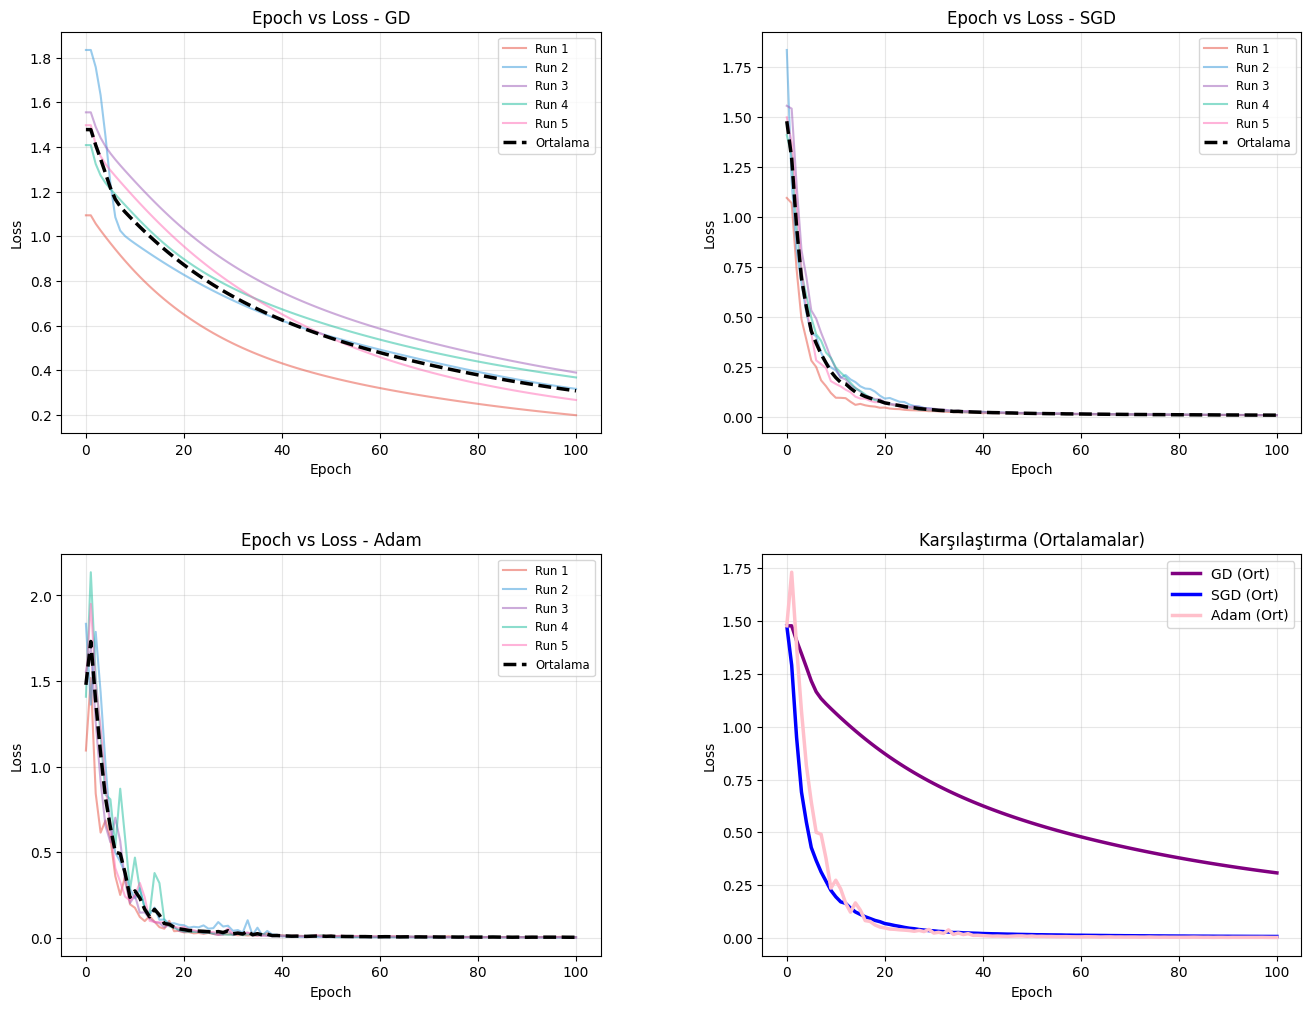

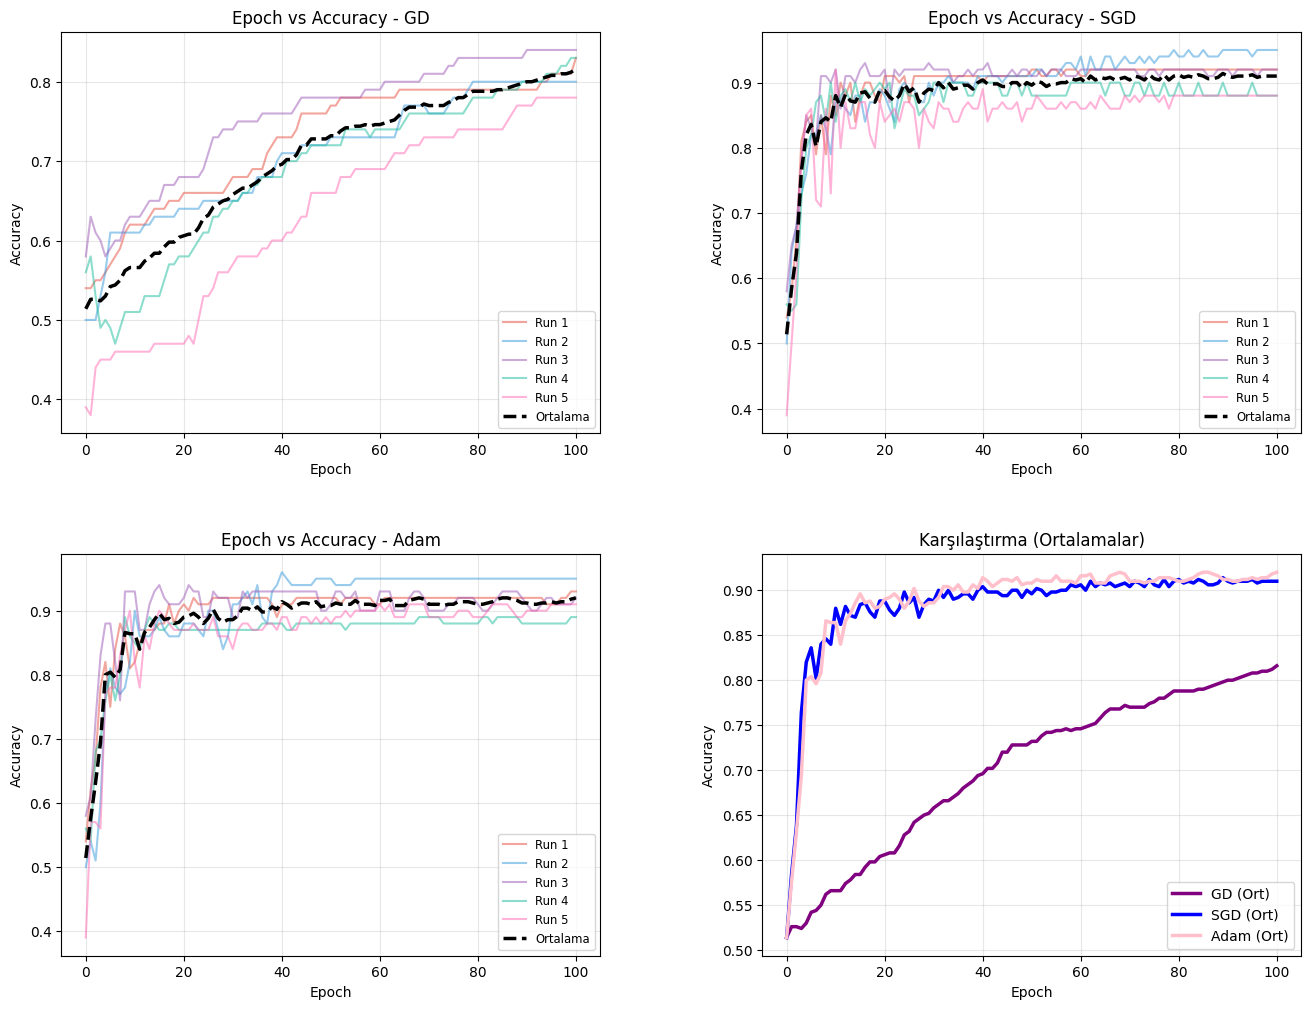

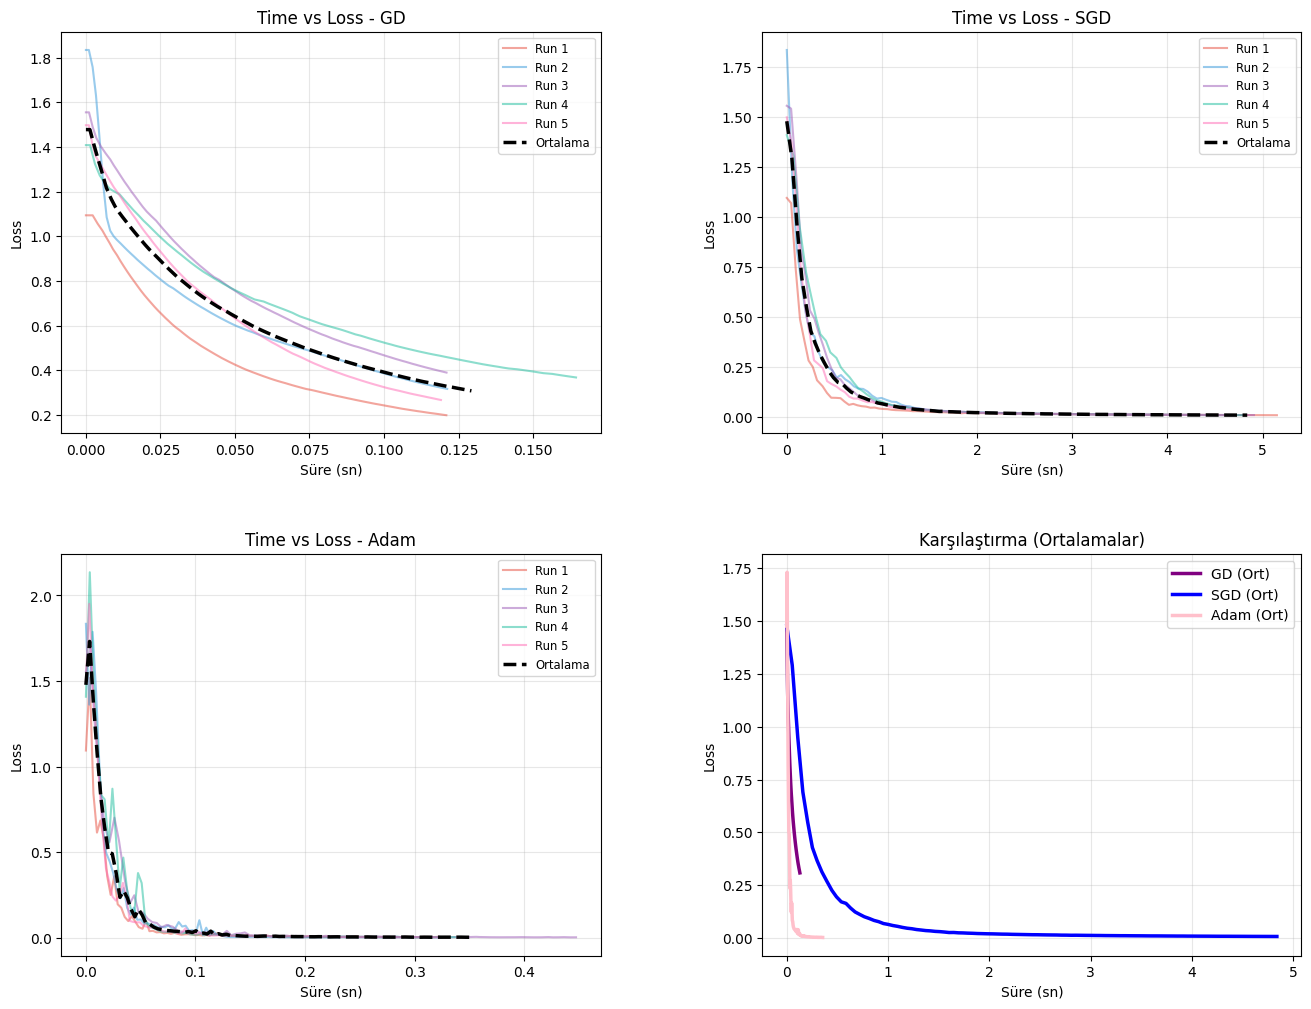

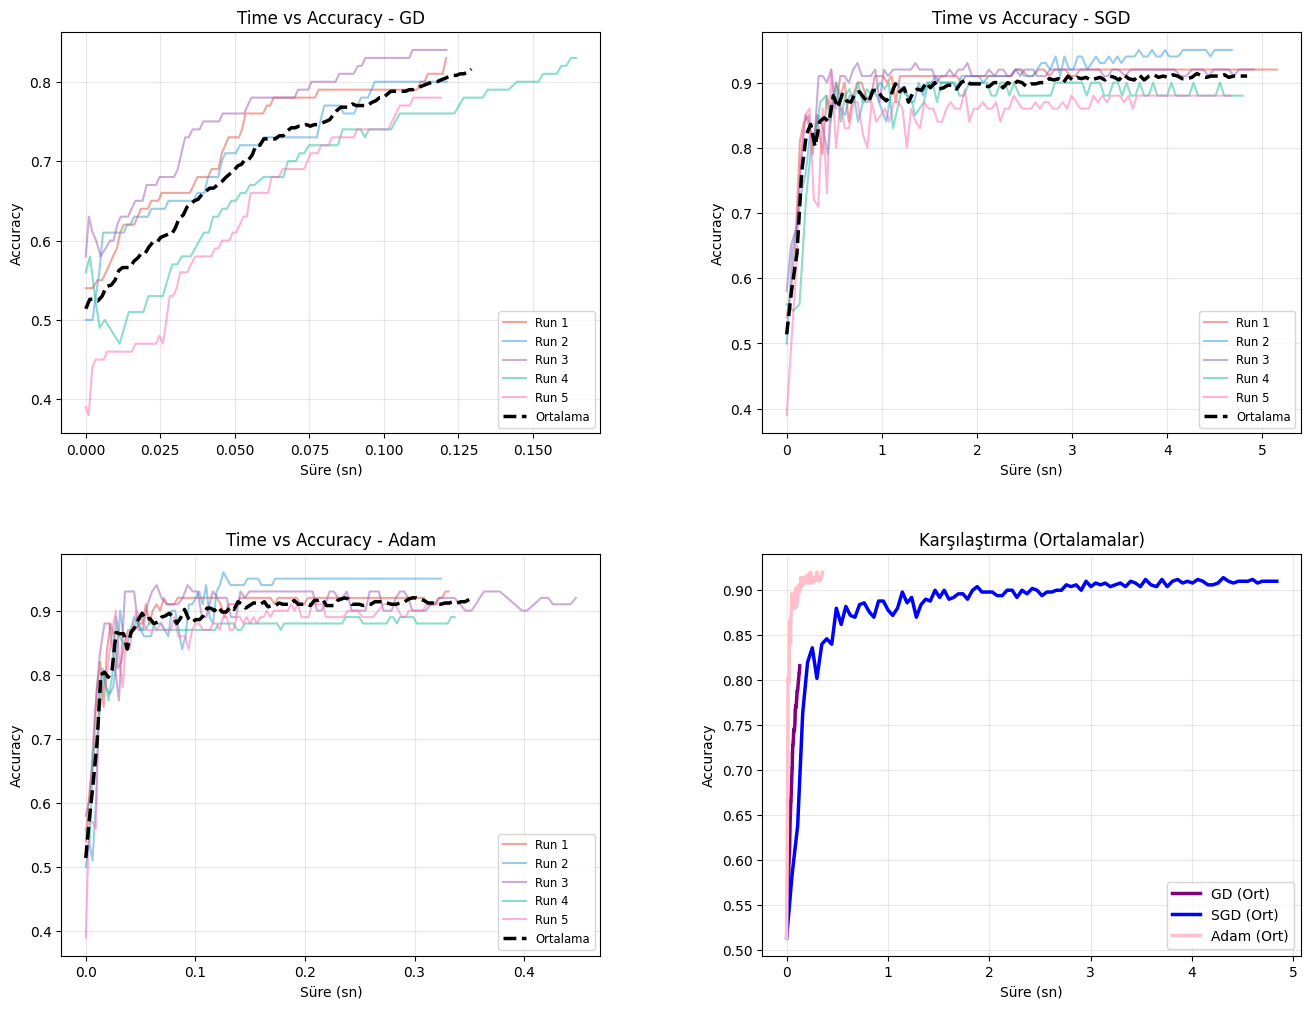


T-SNE Grafikleri Oluşturuluyor...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Grafik çiziliyor...


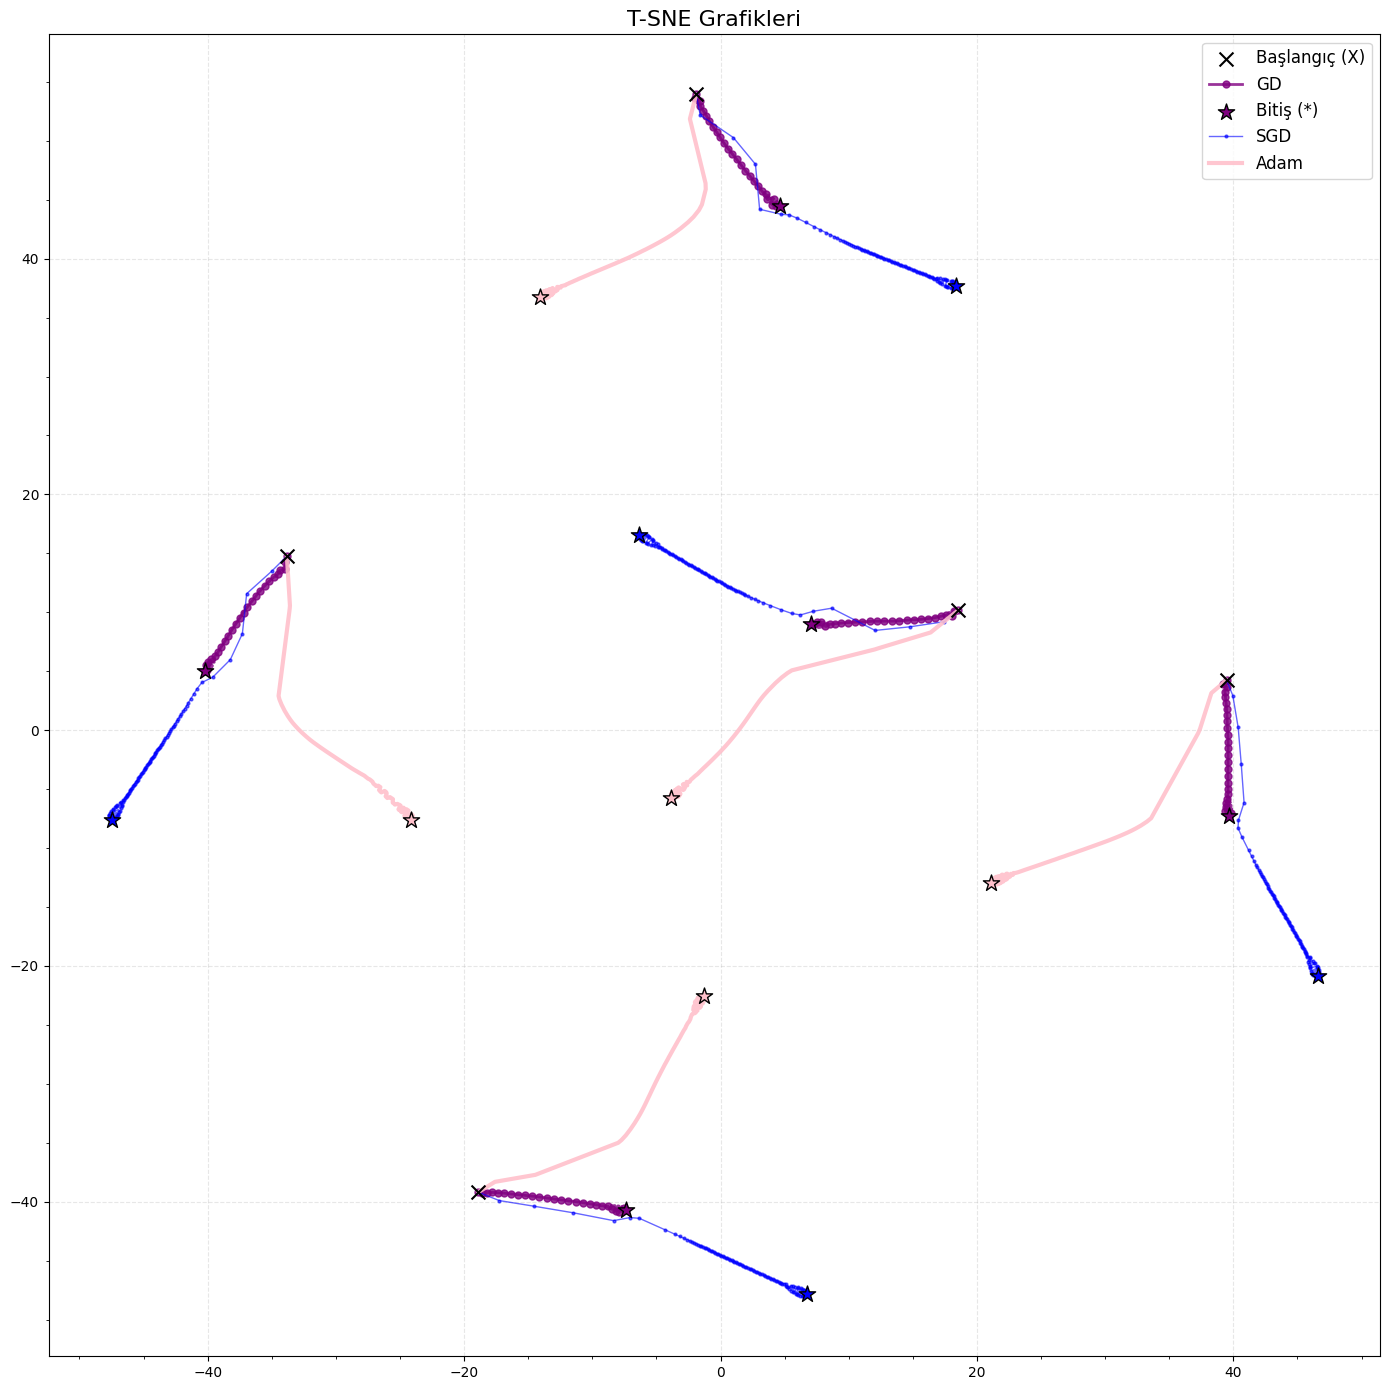

Tüm işlemler tamamlandı


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from huggingface_hub import snapshot_download
from sklearn.manifold import TSNE
import time
import sys

# Data preparation    
print("Veriler işleniyor...")

try:
    # Vectorization model
    embedding_model = SentenceTransformer("ytu-ce-cosmos/turkish-e5-large")

except Exception as e:
    print(f"Model yükleme hatası: {e}")
    sys.exit("Model yükleme hatası nedeniyle işlem sonlandırıldı.")


try:
    # Reads the CSV of the dataset generated with Turkish-Gemma-9bT1
    df = pd.read_csv("train_test.csv")
    print("'train test.csv' başarıyla yüklendi.")
except Exception as e:
    print("Error: 'train_test.csv' dosyası bulunamadı!")
    sys.exit("Dosya eksik olduğu için işlem sonlandırıldı.")



# Vectorization using the ytu-ce cosmos/turkish-e5-large model 
task = 'Given a Turkish search query, retrieve relevant passages that answer the query'

sorular = [f"Instruct: {task}\nQuery: {q}" for q in df['Soru'].tolist()]
cevaplar = df['Cevap'].tolist()

print("Vektörleştirme yapılıyor...")
soru_vecs = embedding_model.encode(sorular, normalize_embeddings=True)
cevap_vecs = embedding_model.encode(cevaplar, normalize_embeddings=True)

# Creating input vector using question vector + answer vector + bias
X_final = np.hstack((soru_vecs, cevap_vecs, np.ones((len(soru_vecs), 1), dtype=np.float32)))
y_final = df['Etiket'].values.reshape(-1, 1).astype(np.float32)


# Separating data based on the "Küme" column
train_mask = df['Küme'] == 'Eğitim'
test_mask = df['Küme'] == 'Test'

# Tensor transformation of Training-Test data
X_train, y_train = torch.tensor(X_final[train_mask]), torch.tensor(y_final[train_mask])
X_test, y_test = torch.tensor(X_final[test_mask]), torch.tensor(y_final[test_mask])

print(f"Eğitim Kümesi Boyutu: {len(X_train)}, Test Kümesi Boyutu: {len(X_test)}")



# Creating the model skeleton
class OdevModeli(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Bias is "False" because a bias column consisting of 1s was already added to X_final
        self.linear = nn.Linear(dim, 1, bias=False)
        self.activation = nn.Tanh()

    # The mathematical operation "tanh(w*x)" of the model
    def forward(self, x):
        return self.activation(self.linear(x))

# Calculate accuracy 
def accuracy(y_pred, y_true):
    return (torch.sign(y_pred) == y_true).float().mean().item()


optimizers = ["GD", "SGD", "Adam"]
runs = 5
epochs = 100

# Variable that tracks how successful the model is
results = {opt: [] for opt in optimizers}

# Variable that keeps track of which path the model took to find the answer
history = {opt: [] for opt in optimizers}

print(f"\n Train: ({runs} Run x {epochs} Epoch)...")
total_start = time.time()

for r in range(runs):
    # 'w' value for each run
    initial_w = torch.randn(1, X_train.shape[1])

    for opt_name in optimizers:
        model = OdevModeli(X_train.shape[1])
        with torch.no_grad():
            # Each algorithm is assigned the 'w' value for that run. Thus, in Run 1 they all start from point w1, and in Run 2 they all start from point w2
            model.linear.weight.copy_(initial_w)

        # Optimization algorithms
        if opt_name == "GD":
            optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
            batch = len(X_train)
        elif opt_name == "SGD":
            optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
            batch = 1
        else: # Adam
            optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
            batch = 32

        criterion = nn.MSELoss()

        run_res = {'loss': [], 'acc': [], 'time': []}
        run_weights = []

        # Initial state record
        with torch.no_grad():
            run_res['acc'].append(accuracy(model(X_test), y_test))
            run_res['loss'].append(criterion(model(X_train), y_train).item())
            run_res['time'].append(0.0)
            run_weights.append(model.linear.weight.data.clone().cpu().numpy().flatten())

        loop_start = time.time()

        for epoch in range(epochs):
            # Mix the data
            perm = torch.randperm(len(X_train))
            Xs, ys = X_train[perm], y_train[perm]

            safe_batch = batch if batch > 0 else 1
            epoch_loss = 0

            # Mini-batch loop
            for i in range(0, len(X_train), safe_batch):
                optimizer.zero_grad()
                out = model(Xs[i:i+safe_batch])
                loss = criterion(out, ys[i:i+safe_batch])
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()


            # End of epoch records, average epoch loss
            run_res['loss'].append(epoch_loss / (len(X_train)/safe_batch))
            run_res['time'].append(time.time() - loop_start)

            with torch.no_grad():
                run_res['acc'].append(accuracy(model(X_test), y_test))

            run_weights.append(model.linear.weight.data.clone().cpu().numpy().flatten())

        results[opt_name].append(run_res)
        history[opt_name].append(run_weights)

    print(f"Run {r+1}/{runs} tamamlandı.")

print(f"Eğitim başarıyla bitti. Toplam Süre: {time.time()-total_start:.2f} sn")


# Graphic Illustrations
print("\nGrafikler Çiziliyor...")

run_colors = ['#E74C3C','#3498DB','#9B59B6','#1ABC9C','#FF69B4']

def visualization(metric_key, y_label, x_key='epoch', title_prefix="", use_log=False):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)

    algo_map = {0: (0,0, 'GD'), 1: (0,1, 'SGD'), 2: (1,0, 'Adam')}

    # Positioning
    if metric_key == 'acc':
        legend_loc = 'lower right'
    else:
        legend_loc = 'upper right'

    # Graphs
    for idx, (r, c, name) in algo_map.items():
        ax = axes[r, c]
        runs_data = results[name]

        for i, run in enumerate(runs_data):
            y_val = run[metric_key]
            x_val = run['time'] if x_key == 'time' else range(len(y_val))
            ax.plot(x_val, y_val, alpha=0.5, linewidth=1.5, color=run_colors[i], label=f'Run {i+1}')

        min_len = min([len(run[metric_key]) for run in runs_data])
        avg_y = np.mean([run[metric_key][:min_len] for run in runs_data], axis=0)

        if x_key == 'time':
            avg_x = np.mean([run['time'][:min_len] for run in runs_data], axis=0)
        else:
            avg_x = range(min_len)

        ax.plot(avg_x, avg_y, 'k--', linewidth=2.5, label='Ortalama')

        ax.set_title(f"{title_prefix} - {name}")
        ax.set_xlabel('Süre (sn)' if x_key == 'time' else 'Epoch')
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.3)
        if use_log and x_key == 'time': ax.set_xscale('log')

        ax.legend(fontsize='small', loc=legend_loc)

    # Comparison Chart
    ax_comp = axes[1, 1]
    comp_colors = {'GD': 'purple', 'SGD': 'blue', 'Adam': 'pink'}

    for name in optimizers:
        runs_data = results[name]
        min_len = min([len(run[metric_key]) for run in runs_data])
        avg_y = np.mean([run[metric_key][:min_len] for run in runs_data], axis=0)
        if x_key == 'time':
            avg_x = np.mean([run['time'][:min_len] for run in runs_data], axis=0)
        else:
            avg_x = range(min_len)
        ax_comp.plot(avg_x, avg_y, label=f"{name} (Ort)", color=comp_colors[name], linewidth=2.5)

    ax_comp.set_title("Karşılaştırma (Ortalamalar)")
    ax_comp.set_xlabel('Süre (sn)' if x_key == 'time' else 'Epoch')
    ax_comp.set_ylabel(y_label)
    ax_comp.legend(loc=legend_loc)
    ax_comp.grid(True, alpha=0.3)
    if use_log and x_key == 'time': ax_comp.set_xscale('log')

    plt.show()

#Epoch graphs
visualization('loss', 'Loss', x_key='epoch', title_prefix="Epoch vs Loss")
visualization('acc', 'Accuracy', x_key='epoch', title_prefix="Epoch vs Accuracy")

# Time graphs
visualization('loss', 'Loss', x_key='time', title_prefix="Time vs Loss", use_log=False)
visualization('acc', 'Accuracy', x_key='time', title_prefix="Time vs Accuracy", use_log=False)


# T-SNE calculations
print("\nT-SNE Grafikleri Oluşturuluyor...")

all_weights_flat = []
for r in range(runs):
    for opt in optimizers:
        all_weights_flat.extend(history[opt][r])

# Calculating part
tsne = TSNE(n_components=2, perplexity=40, n_iter=1500, init='pca', learning_rate='auto', random_state=42)
X_embedded = tsne.fit_transform(np.array(all_weights_flat))

plot_data = {opt: {r: [] for r in range(runs)} for opt in optimizers}
curr_idx = 0
for r in range(runs):
    for opt in optimizers:
        step_count = len(history[opt][r])
        plot_data[opt][r] = X_embedded[curr_idx : curr_idx + step_count]
        curr_idx += step_count

print("Grafik çiziliyor...")
plt.figure(figsize=(14, 14))

styles = {
    'GD': {'color': 'purple', 'lw': 2.0, 'alpha': 0.8, 'marker': 'o', 'ms': 5, 'markevery': 4},
    'SGD': {'color': 'blue', 'lw': 1.0, 'alpha': 0.6, 'marker': '.', 'ms': 4, 'markevery': 1},
    'Adam': {'color': 'pink', 'lw': 3.0, 'alpha': 0.9, 'marker': None, 'ms': 0, 'markevery': 0}
}

labels = []
for r in range(runs):
    start_pt = plot_data['GD'][r][0]
    plt.scatter(start_pt[0], start_pt[1], c='black', marker='x', s=100, zorder=10,
                label='Başlangıç (X)' if r==0 else "")

    for opt in optimizers:
        traj = plot_data[opt][r]
        st = styles[opt]
        lbl = opt if opt not in labels else ""
        if lbl: labels.append(lbl)

        plt.plot(traj[:, 0], traj[:, 1], color=st['color'], linewidth=st['lw'],
                 alpha=st['alpha'], marker=st['marker'], markersize=st['ms'],
                 markevery=st.get('markevery', None), label=lbl)

        plt.scatter(traj[-1, 0], traj[-1, 1], facecolors=st['color'], edgecolors='black',
                    marker='*', s=150, zorder=10,
                    label='Bitiş (*)' if r==0 and opt=='GD' else "")

plt.title("T-SNE Grafikleri", fontsize=16)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.minorticks_on()
plt.tight_layout()
plt.show()
print("Tüm işlemler tamamlandı")